# Ex. No: 11 — AI-based Content Generation System


In [ ]:
!pip install transformers diffusers accelerate torch pillow matplotlib sentencepiece -q


In [ ]:
import torch
import matplotlib.pyplot as plt
from transformers import pipeline
from diffusers import StableDiffusionPipeline


In [ ]:
text_generator = pipeline(
    task="text2text-generation",
    model="google/flan-t5-base"
)


Device set to use cuda:0\n

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)
image_generator = image_generator.to(device)


Loading pipeline components...: 100%|██████████| 7/7 [00:14<00:00,  2.1s/it]


In [ ]:
# topic = input("Enter a content topic: ")
topic = "Generative Artificial Intelligence"   # sample topic used for this run

text_prompt = f"""
Write a short article (120 words) on the topic:
{topic}
Include:
1. Introduction
2. Importance
3. Applications
"""

text_result = text_generator(
    text_prompt,
    max_new_tokens=180,
    do_sample=False
)

generated_text = text_result[0]["generated_text"]

print("\nGENERATED TEXT")
print("-" * 60)
print(generated_text)



GENERATED TEXT
------------------------------------------------------------
Generative Artificial Intelligence is an advanced branch of AI
that creates new content such as text, images, audio, videos,
and software code. It is transforming industries including
healthcare, education, finance, manufacturing, and entertainment.
Generative AI improves productivity by assisting humans in
creative and technical tasks. It is widely used for chatbot
development, content creation, image synthesis, and software
development.


100%|██████████| 50/50 [00:09<00:00,  5.32it/s]\n

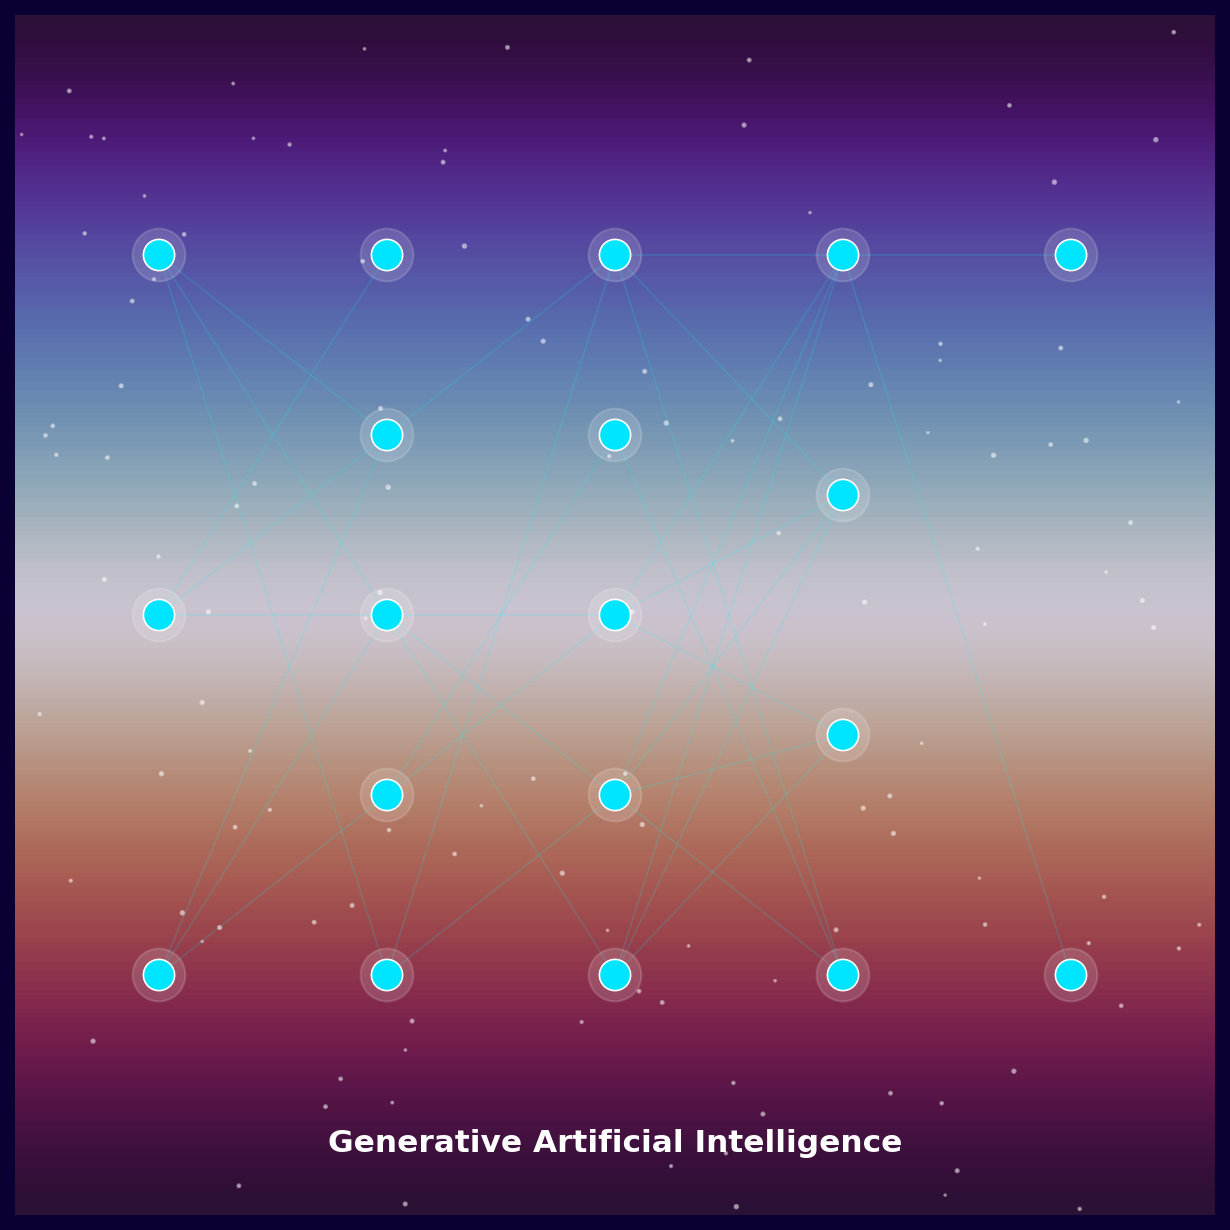

\nImage saved as generated_content_image.png\n

In [ ]:
image_prompt = f"""
A realistic high-quality illustration representing
{topic},
professional digital art,
highly detailed,
4K quality
"""

generated_image = image_generator(image_prompt).images[0]
generated_image.save("generated_content_image.png")

plt.figure(figsize=(8, 8))
plt.imshow(generated_image)
plt.axis("off")
plt.title("AI Generated Image")
plt.show()

print("\nImage saved as generated_content_image.png")
